# Am I Cooked?
## Predicting Whether College Students Get Hired

### Team Members
- NJ Lacambra
- Hubert Ferro
- Fabio Jorge

## Hubert's Contribution
Data loading, cleaning, preprocessing, exploratory data analysis, Logistic Regression, and Random Forest.

## Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("college_student_placement_dataset.csv")

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [3]:
df["GPA"] = (df["CGPA"] * 0.4).clip(upper=4.0)

df["GPA"] = df["GPA"].round(2)

df[["CGPA", "GPA"]].head()

,CGPA,GPA
0,6.28,2.51
1,5.37,2.15
2,5.83,2.33
3,5.75,2.30
4,7.69,3.08


GPA was added as a 4.0 scale version of CGPA to make the data easier to understand for an American audience. The original CGPA is still used in the prediction models.

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Dataset Shape:
(10000, 11)

Column Names:
['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement', 'GPA']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
 10  GPA  

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
GPA                       0
dtype: int64


### Missing Values

There are no missing values in the dataset, so no missing data needs to be filled or removed.

In [6]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [7]:
print("Placement Counts:")
print(df["Placement"].value_counts())

print("\nPlacement Percentages:")
print(df["Placement"].value_counts(normalize=True) * 100)

Placement Counts:
Placement
No     8341
Yes    1659
Name: count, dtype: int64

Placement Percentages:
Placement
No     83.41
Yes    16.59
Name: proportion, dtype: float64


### Placement Distribution

The dataset is imbalanced. About 83.41% of students were not placed, while 16.59% were placed. Because of this imbalance, accuracy alone may not be the best way to evaluate the models. Balanced accuracy and F1-score will also be important.

In [8]:
X = df.drop(columns=["College_ID", "Placement", "GPA"])
y = df["Placement"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X.head()

X Shape: (10000, 8)
y Shape: (10000,)


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,107,6.61,6.28,8,No,8,8,4
1,97,5.52,5.37,8,No,7,8,0
2,109,5.36,5.83,9,No,3,1,1
3,122,5.47,5.75,6,Yes,1,6,1
4,96,7.91,7.69,7,No,8,10,2


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 8)
X_test: (2000, 8)
y_train: (8000,)
y_test: (2000,)


In [10]:
numerical_features = [
    "IQ",
    "Prev_Sem_Result",
    "CGPA",
    "Academic_Performance",
    "Extra_Curricular_Score",
    "Communication_Skills",
    "Projects_Completed"
]

categorical_features = [
    "Internship_Experience"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed']

Categorical Features:
['Internship_Experience']


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [12]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Training Data Shape:", X_train_prep.shape)
print("Testing Data Shape:", X_test_prep.shape)

Training Data Shape: (8000, 9)
Testing Data Shape: (2000, 9)


## Exploratory Data Analysis (EDA)

### Distribution of Numerical Features

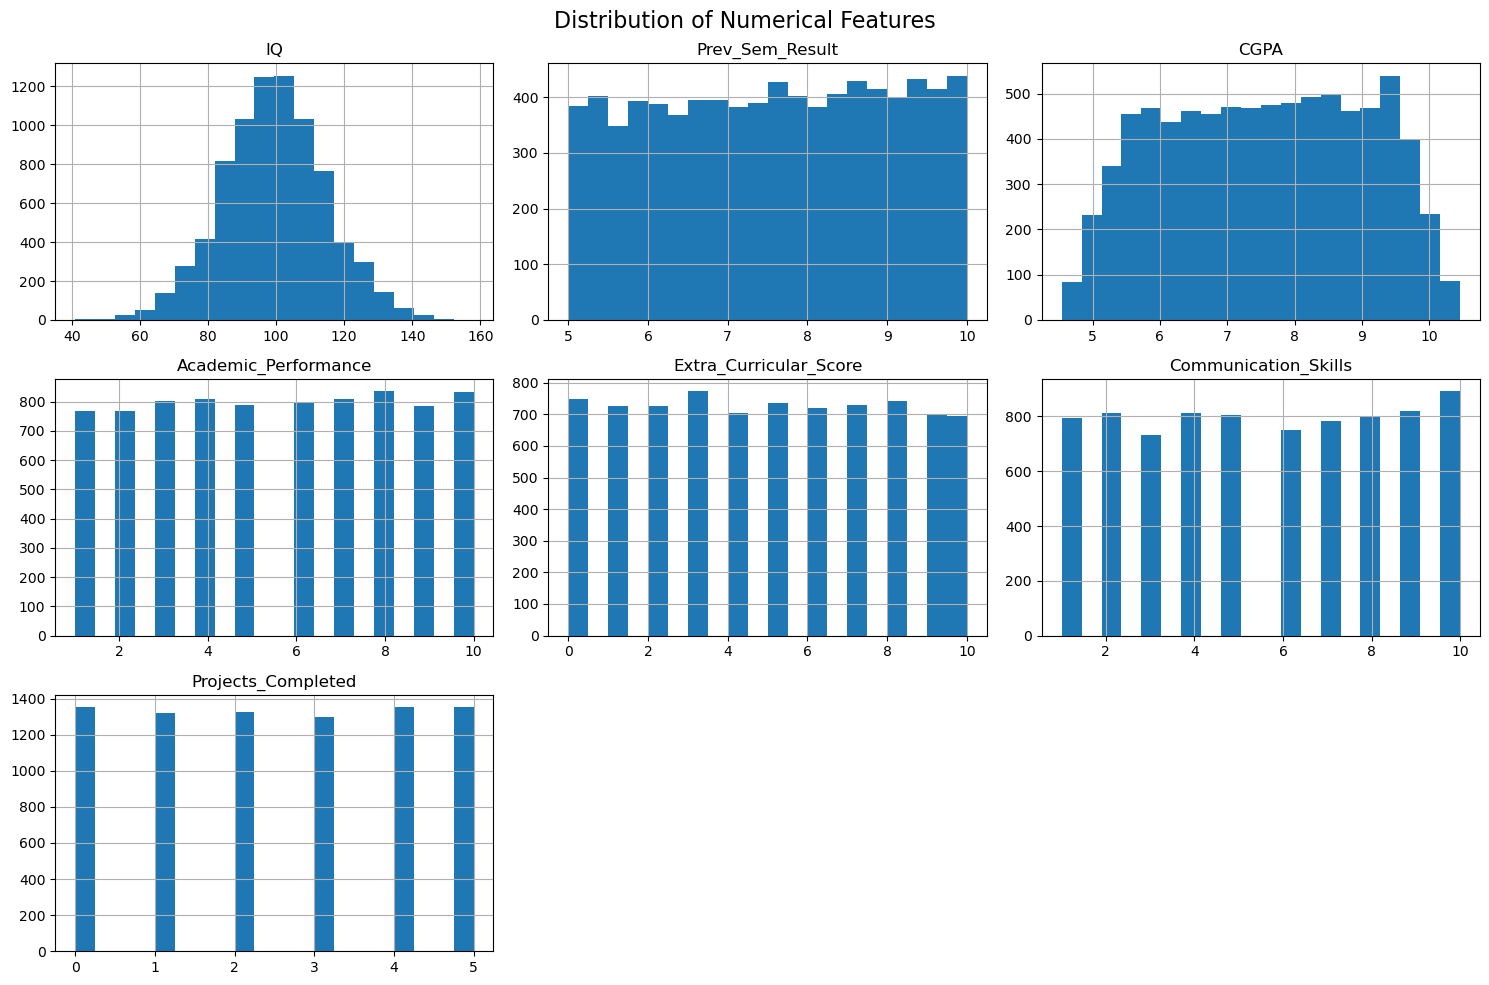

In [13]:
X_train[numerical_features].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

### Interpretation

The graphs show how the values are spread out for each feature. Most of the data looks normal and doesn't have any obvious problems, so it should be good to use for training the models.

### Correlation Heatmap

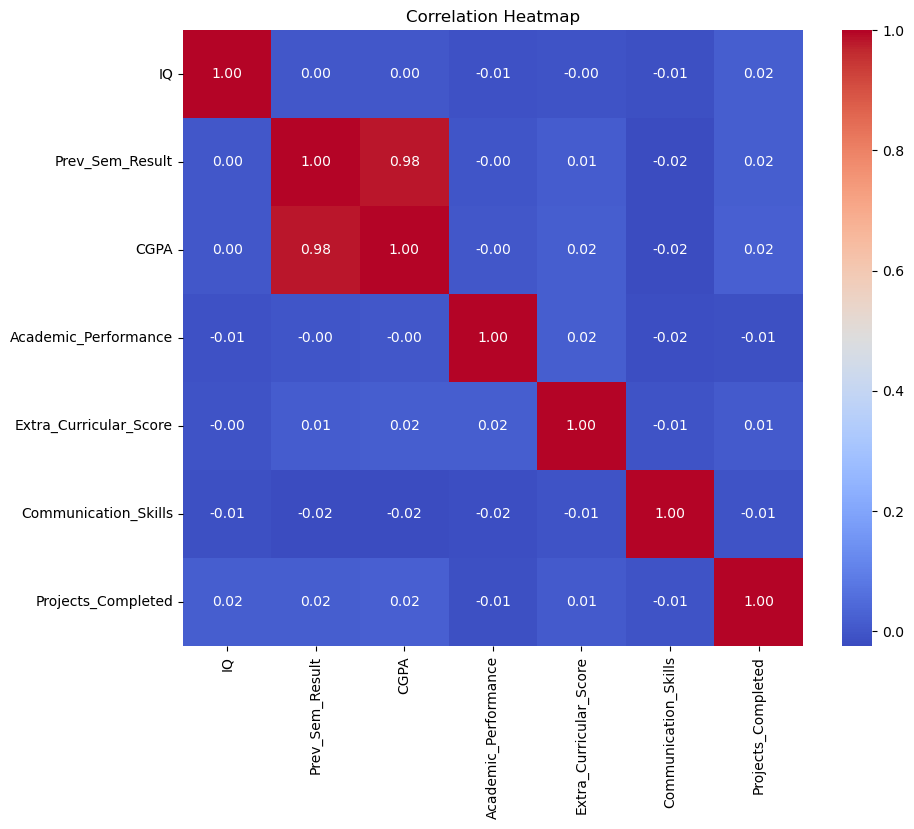

In [14]:
plt.figure(figsize=(10, 8))

correlation_matrix = X_train[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The heatmap shows how the numerical features are related to each other. Most of the values are low, which means the features aren't strongly connected. This is good because each feature can help the model in a different way.

### Internship Experience vs Placement

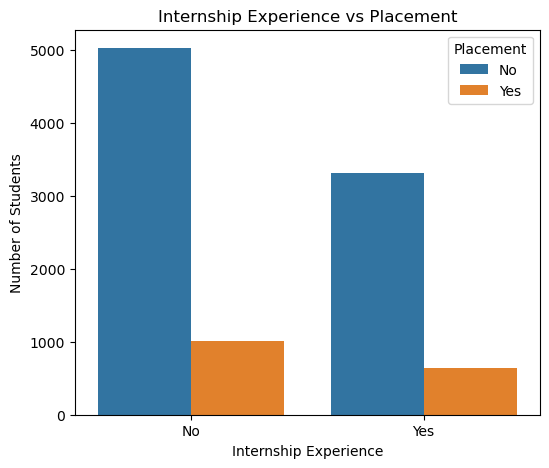

In [15]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Internship_Experience",
    hue="Placement"
)

plt.title("Internship Experience vs Placement")
plt.xlabel("Internship Experience")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

Students with internship experience appear to have different placement outcomes compared to students without internship experience. This visualization helps determine whether internship experience may be an important feature for predicting placement.

### Boxplots by Placement

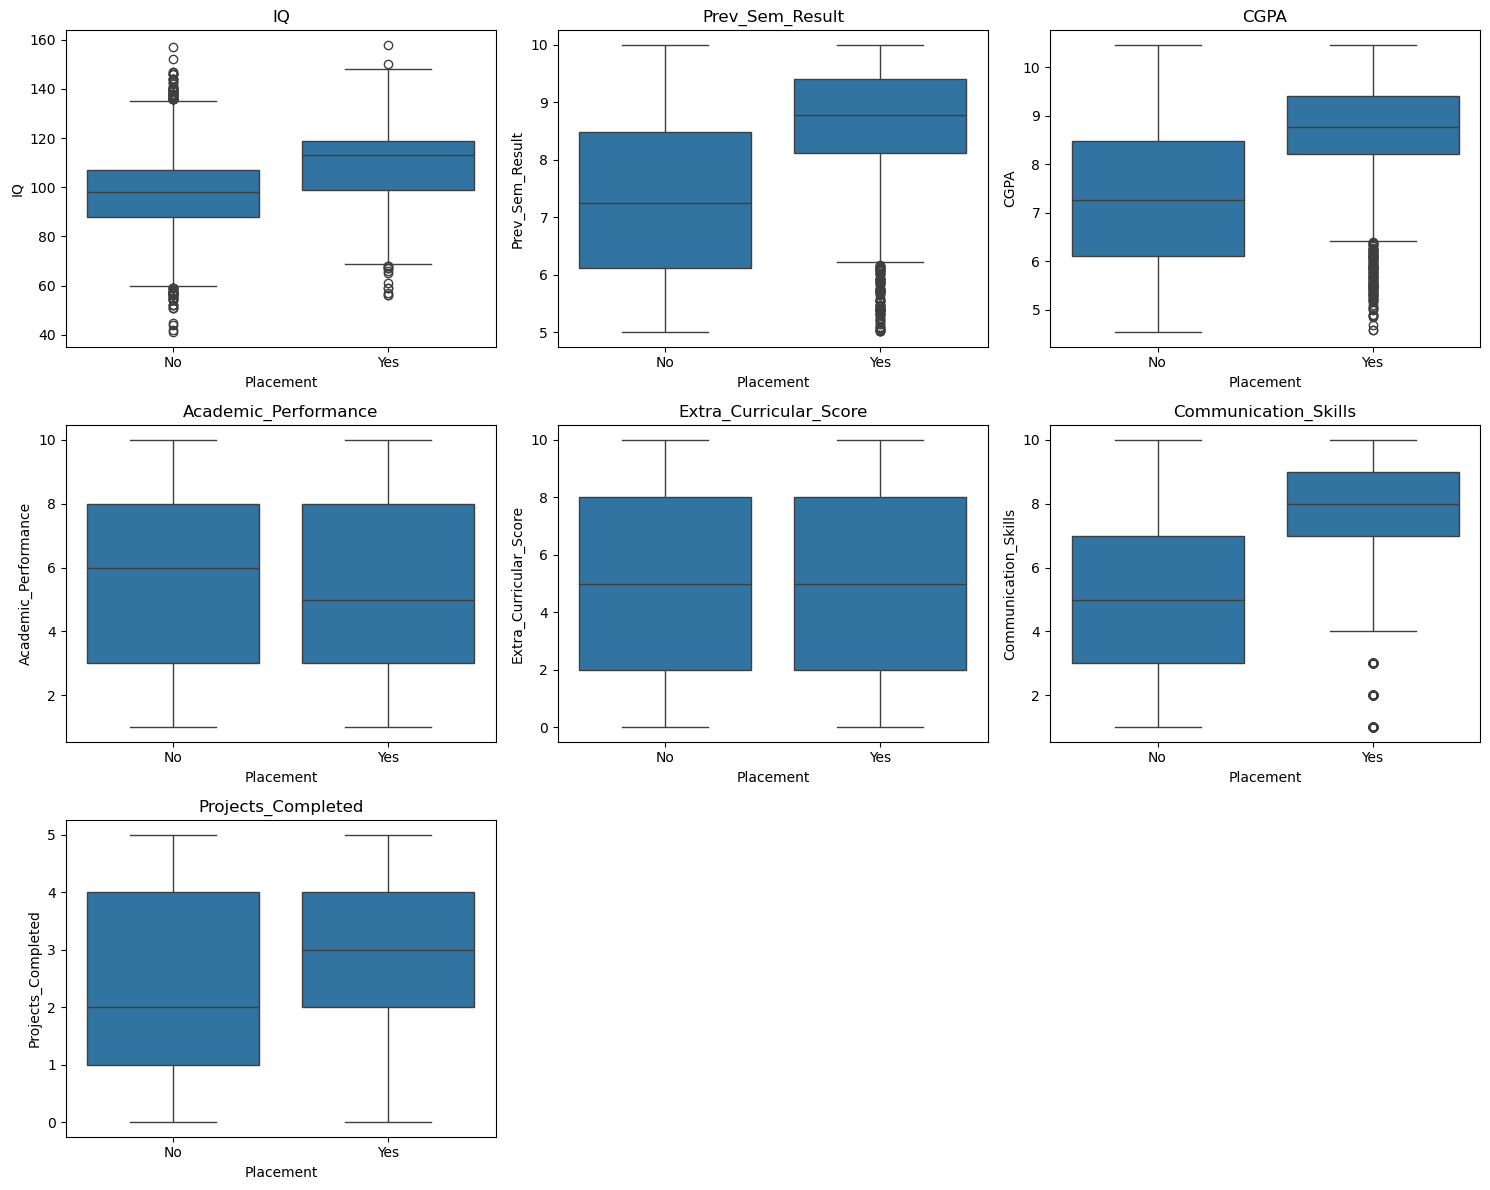

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x="Placement",
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(feature)

# Hide unused subplot
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretation

The boxplots compare each numerical feature for placed and non placed students. They help identify differences in the distributions and highlight which features may be associated with successful placement.

## Model Implementation and Evaluation

### 3.1 Stratified K-Fold Cross Validation

In [17]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### Explanation

Stratified K-Fold Cross Validation splits the training data into five folds while preserving the same class distribution in each fold. This provides a more reliable evaluation of each machine learning model than using a single train-test split.

### 3.2 Logistic Regression (Baseline)

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

logistic_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Cross-validation completed!")

Cross-validation completed!


### Explanation

A Logistic Regression model is used as the baseline classifier. The model is evaluated using 5-fold Stratified Cross Validation with four evaluation metrics: Accuracy, Balanced Accuracy, Macro F1-score, and Weighted F1-score.

In [19]:
print("Logistic Regression Results")

print(f"Mean Accuracy: {logistic_results['test_accuracy'].mean():.4f}")
print(f"Mean Balanced Accuracy: {logistic_results['test_balanced_accuracy'].mean():.4f}")
print(f"Mean Macro F1: {logistic_results['test_f1_macro'].mean():.4f}")
print(f"Mean Weighted F1: {logistic_results['test_f1_weighted'].mean():.4f}")

Logistic Regression Results
Mean Accuracy: 0.9025
Mean Balanced Accuracy: 0.7837
Mean Macro F1: 0.8079
Mean Weighted F1: 0.8980


### Interpretation

Logistic Regression gives us a starting point to compare with the other models. The accuracy is good, but the balanced accuracy and F1 scores are more useful because there are more students who were not placed than placed. We'll compare these results with Random Forest to see which model does better.

### 3.3 Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

random_forest_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Random Forest cross-validation completed!")

Random Forest cross-validation completed!


In [21]:
print("Random Forest Results")

print(f"Mean Accuracy: {random_forest_results['test_accuracy'].mean():.4f}")
print(f"Mean Balanced Accuracy: {random_forest_results['test_balanced_accuracy'].mean():.4f}")
print(f"Mean Macro F1: {random_forest_results['test_f1_macro'].mean():.4f}")
print(f"Mean Weighted F1: {random_forest_results['test_f1_weighted'].mean():.4f}")

Random Forest Results
Mean Accuracy: 0.9996
Mean Balanced Accuracy: 0.9989
Mean Macro F1: 0.9993
Mean Weighted F1: 0.9996


### Interpretation

The Random Forest model was tested using the same method as Logistic Regression, so the results can be compared fairly. Since the data has more students who were not placed, the balanced accuracy and F1 scores are the most helpful for judging how well the model performs.

In [22]:
random_forest_pipeline.fit(X_train, y_train)

trained_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
trained_random_forest = random_forest_pipeline.named_steps["classifier"]

feature_names = trained_preprocessor.get_feature_names_out()
feature_importances = trained_random_forest.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
5,num__Communication_Skills,0.287174
0,num__IQ,0.240360
6,num__Projects_Completed,0.208695
2,num__CGPA,0.150033
1,num__Prev_Sem_Result,0.100029
4,num__Extra_Curricular_Score,0.005949
3,num__Academic_Performance,0.005687
8,cat__Internship_Experience_Yes,0.001101
7,cat__Internship_Experience_No,0.000972


### Feature Importance

Random Forest can estimate how important each feature is when making predictions. Larger values indicate that the feature contributes more to the model's decisions.

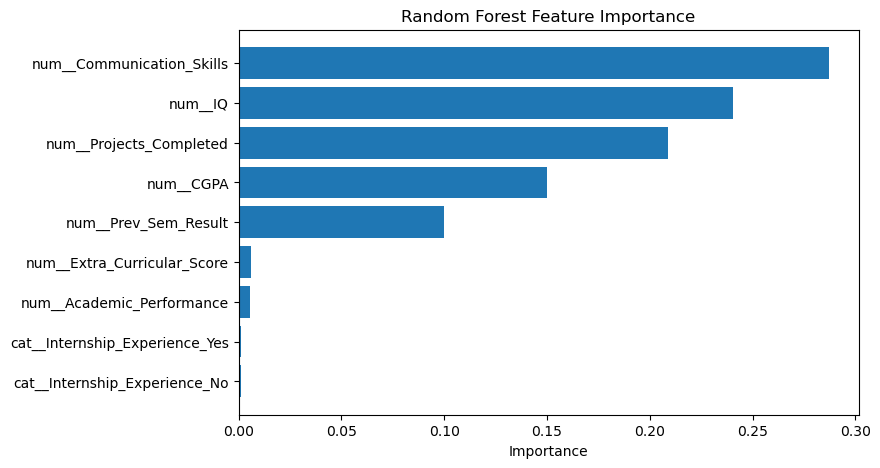

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

### Interpretation

Communication Skills, IQ, and Projects Completed are the most influential features in predicting whether a student is placed. Internship Experience contributes the least in this dataset, while CGPA and Previous Semester Result also play meaningful roles.

### 3.5 Model Comparison

In [24]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Mean Accuracy": [
        logistic_results["test_accuracy"].mean(),
        random_forest_results["test_accuracy"].mean()
    ],

    "Mean Balanced Accuracy": [
        logistic_results["test_balanced_accuracy"].mean(),
        random_forest_results["test_balanced_accuracy"].mean()
    ],

    "Mean Macro F1": [
        logistic_results["test_f1_macro"].mean(),
        random_forest_results["test_f1_macro"].mean()
    ],

    "Mean Weighted F1": [
        logistic_results["test_f1_weighted"].mean(),
        random_forest_results["test_f1_weighted"].mean()
    ],

    "Macro F1 Std": [
        logistic_results["test_f1_macro"].std(),
        random_forest_results["test_f1_macro"].std()
    ]
})

comparison_df

,Model,Mean Accuracy,Mean Balanced Accuracy,Mean Macro F1,Mean Weighted F1,Macro F1 Std
0,Logistic Regression,0.902500,0.783677,0.807891,0.897978,0.007399
1,Random Forest,0.999625,0.998871,0.999321,0.999625,0.000905


In [25]:
best_model_name = comparison_df.loc[
    comparison_df["Mean Macro F1"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


### 3.6 Hyperparameter Tuning

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Macro F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best Macro F1 Score:
0.9995


In [27]:
best_model = grid_search.best_estimator_

print("Best model saved.")

Best model saved.


### 3.7 Cross-Validated Predictions

In [28]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

print("Cross-validated predictions completed.")
print("Number of predictions:", len(y_train_pred))

Cross-validated predictions completed.
Number of predictions: 8000


### 3.8 Confusion Matrix

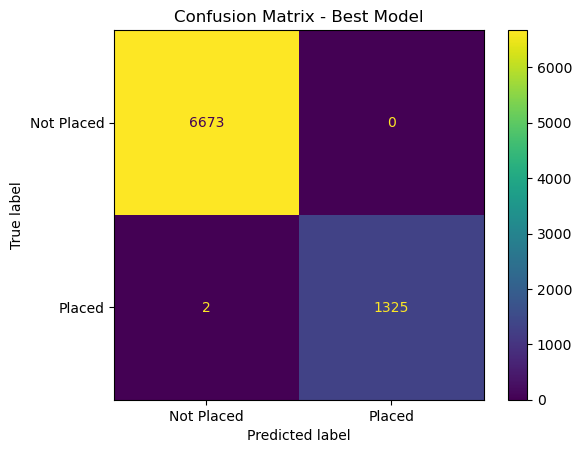

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_train_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.show()

### 3.9 Classification Report

In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_train,
    y_train_pred,
    target_names=["Not Placed", "Placed"]
))

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00      6673
      Placed       1.00      1.00      1.00      1327

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



#### Interpretation

The model performed very well for both classes. Precision, recall, and F1-score are all close to 1.00 for both Not Placed and Placed students. Out of 8,000 predictions, the model only made 2 mistakes. This shows that the model is able to predict both classes very accurately, even though the dataset has more Not Placed students than Placed students.

### 3.10 ROC-AUC Curve

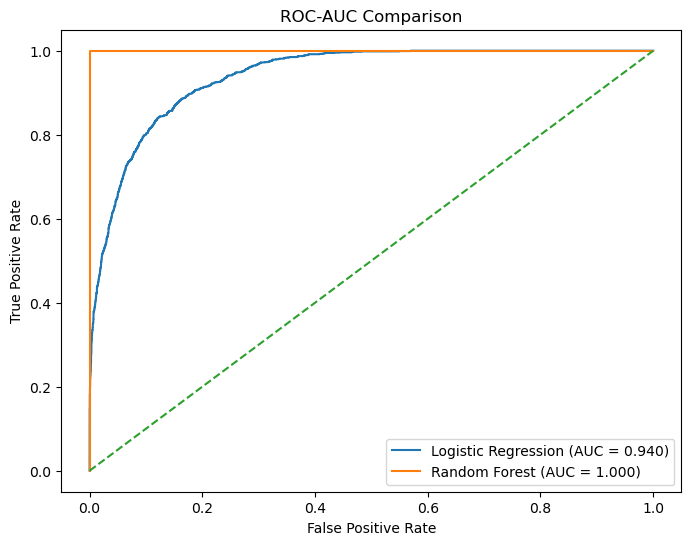

Logistic Regression AUC: 0.9403
Random Forest AUC: 1.0


In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

logistic_pipeline.fit(X_train, y_train)

logistic_probs = logistic_pipeline.predict_proba(X_train)[:, 1]
random_forest_probs = best_model.predict_proba(X_train)[:, 1]

log_fpr, log_tpr, _ = roc_curve(
    y_train,
    logistic_probs,
    pos_label="Yes"
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_train,
    random_forest_probs,
    pos_label="Yes"
)

log_auc = auc(log_fpr, log_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()

plt.show()

print("Logistic Regression AUC:", round(log_auc, 4))
print("Random Forest AUC:", round(rf_auc, 4))

#### Interpretation

The Random Forest model performed better on the ROC-AUC comparison. Its AUC score was 1.00, while Logistic Regression had an AUC of about 0.94. This means Random Forest was better at separating students who were placed from students who were not placed.

### 3.11 Feature Importance Analysis

In [32]:
trained_preprocessor = best_model.named_steps["preprocessor"]
trained_random_forest = best_model.named_steps["classifier"]

feature_names = trained_preprocessor.get_feature_names_out()
feature_importances = trained_random_forest.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance_df.head(10)

top_features

,Feature,Importance
5,num__Communication_Skills,0.289553
0,num__IQ,0.250242
6,num__Projects_Completed,0.204135
2,num__CGPA,0.154815
1,num__Prev_Sem_Result,0.089475
4,num__Extra_Curricular_Score,0.005647
3,num__Academic_Performance,0.004470
7,cat__Internship_Experience_No,0.000882
8,cat__Internship_Experience_Yes,0.000780


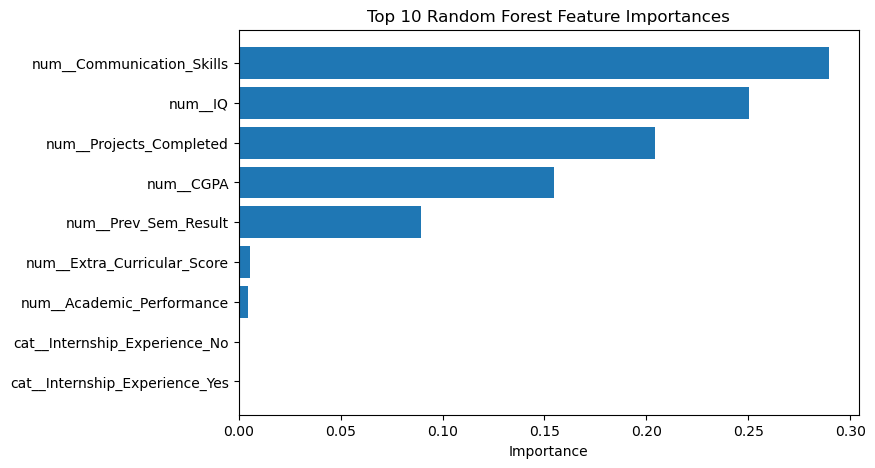

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()

plt.show()

#### Interpretation

The feature importance results show which variables had the biggest effect on the Random Forest model's predictions. Communication Skills, IQ, Projects Completed, CGPA, and Previous Semester Result were among the most important features. Features with larger importance values had a stronger influence on whether the model predicted that a student would be placed.

### 3.12 Final Model Evaluation on Test Set

In [34]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Make predictions on the test set
y_test_pred = best_model.predict(X_test)

# Calculate final metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

print("Final Test Results")
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Macro F1:", round(test_macro_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Not Placed", "Placed"]
))

Final Test Results
Test Accuracy: 0.9995
Test Macro F1: 0.9991

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00      1668
      Placed       1.00      1.00      1.00       332

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



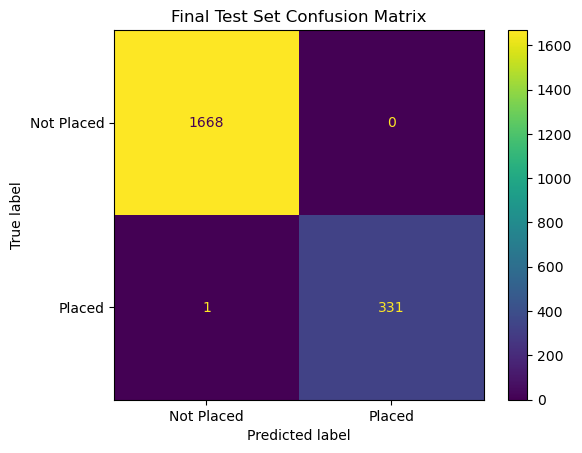

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()
plt.title("Final Test Set Confusion Matrix")
plt.show()

#### Interpretation

The final Random Forest model performed very well on the test data. It correctly predicted 1,668 Not Placed students and 331 Placed students. The model only made one incorrect prediction out of 2,000 students. This shows that the model also performs well on data that was not used for training.